In [1]:
# Google Colab Notebook: Clasificación de frutas con CNN

# ============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import os
# from google.colab import files
import zipfile
from tensorflow.keras import regularizers

from tensorflow.keras.applications.resnet50 import preprocess_input


In [2]:
# ============================
# 2. CARGA Y PREPROCESAMIENTO DE DATOS
# ============================
import os

# Define directamente la ruta de la carpeta que has descomprimido
base_dir = r"C:\Users\Usuario\programacion\bootcampIA\Dataset Tipo de Plantas"

# Directorios de Entrenamiento, Validación y Prueba
train_dir = os.path.join(base_dir, 'Entrenamiento')
val_dir = os.path.join(base_dir, 'Validación')
test_dir = os.path.join(base_dir, 'Prueba')

# Tamaño y batch
img_size = (224, 224)
batch_size = 32

# Generadores de datos normalizados
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
val_data = val_datagen.flow_from_directory(val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
test_data = test_datagen.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

Found 5593 images belonging to 7 classes.
Found 706 images belonging to 7 classes.
Found 700 images belonging to 7 classes.


In [3]:
# ============================
# 3. DISEÑO DE LA CNN (Transfer Learning con ResNet50)
# ============================
from tensorflow.keras.applications import ResNet50

# Cargar el modelo base preentrenado con pesos de ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar las capas del modelo base
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Global average pooling
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [4]:
# ============================
# 4. COMPILACIÓN Y ENTRENAMIENTO
# ============================
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Optimizador Adam con tasa 0.001
              loss='categorical_crossentropy',  # Pérdida adecuada para clasificación multiclase
              metrics=['accuracy'])  # Métrica de precisión

start_time = time.time()  # Iniciar cronómetro
# early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#history = model.fit(train_data, epochs=20, validation_data=val_data, callbacks=[early_stop])  # Entrenamiento por 20 épocas
history = model.fit(train_data, epochs=10, validation_data=val_data)
training_time = time.time() - start_time  # Tiempo total
print(f"\nTiempo de entrenamiento: {training_time:.2f} segundos")


Epoch 1/10
 78/175 ━━━━━━━━━━━━━━━━━━━━ 2:29 2s/step - accuracy: 0.2871 - loss: 2.5979

KeyboardInterrupt: 

In [ ]:
# ============================
# 4.1 FINE-TUNING (AJUSTE FINO)
# ============================
# 1. Descongelar el modelo base
base_model.trainable = True

# 2. Volver a congelar todas las capas EXCEPTO las últimas 30
# Esto permite ajustar solo las características de alto nivel
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Re-compilar con un Learning Rate mucho menor (1e-5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Modelo re-compilado para Fine-Tuning.")
model.summary()

# 4. Continuar el entrenamiento por unas pocas épocas extra
fine_tune_epochs = 5
total_epochs = 10 + fine_tune_epochs

history_fine = model.fit(train_data,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=val_data)


In [ ]:
# ============================
# 5. EVALUACIÓN DEL MODELO
# ============================
test_loss, test_acc = model.evaluate(test_data)  # Evaluación final
print(f"Precisión en prueba: {test_acc:.2f}")

predictions = model.predict(test_data)  # Obtener predicciones
y_pred = np.argmax(predictions, axis=1)  # Convertir de one-hot a etiquetas
y_true = test_data.classes  # Etiquetas verdaderas
class_labels = list(test_data.class_indices.keys())  # Nombres de clases

# Reporte detallado: precisión, recall, F1 por clase
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_labels))


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.6014 - loss: 1.1140
Precisión en prueba: 0.60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

    aloevera       0.54      0.91      0.68       100
      banana       0.60      0.90      0.72       100
     coconut       0.62      0.68      0.65       100
       mango       0.57      0.04      0.07       100
      orange       0.46      0.28      0.35       100
      papaya       0.54      0.74      0.62       100
  watermelon       0.97      0.66      0.79       100

    accuracy                           0.60       700
   macro avg       0.62      0.60      0.55       700
weighted avg       0.62      0.60      0.55       700



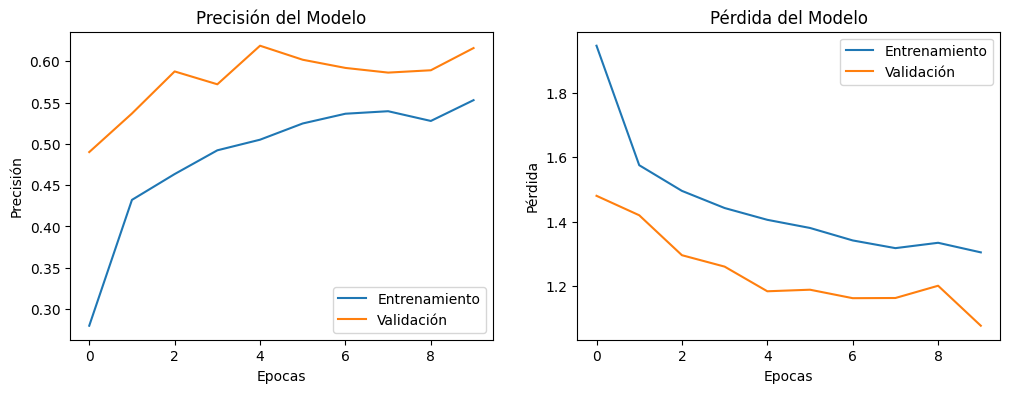

Diagnóstico: Buen ajuste


In [ ]:
# ============================
# 6. VISUALIZACIÓN DE MÉTRICAS
# ============================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Epocas')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Epocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Diagnóstico del modelo: overfitting, underfitting o buen ajuste
train_loss_final = history.history['loss'][-1]
val_loss_final = history.history['val_loss'][-1]

if val_loss_final > train_loss_final * 1.3:
    print("Diagnóstico: Overfitting")
elif val_loss_final < train_loss_final * 0.7:
    print("Diagnóstico: Underfitting")
else:
    print("Diagnóstico: Buen ajuste")


In [ ]:
# ============================
# 7. VISUALIZACIÓN DE FILTROS
# ============================
# ResNet50 está en model.layers[0], llamamos a su primera capa convolucional 'conv1_conv'
first_conv_layer = model.layers[0].get_layer('conv1_conv')
filters, biases = first_conv_layer.get_weights()  # Obtener filtros

# Normalizar valores para visualizar mejor
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = 6  # Número de filtros a mostrar
plt.figure(figsize=(10, 4))
for i in range(n_filters):
    f = filters[:, :, :, i]  # Seleccionar filtro i
    plt.subplot(1, n_filters, i + 1)
    plt.imshow(f[:, :, 0], cmap='gray')  # Mostrar un canal (RGB)
    plt.axis('off')
    plt.title(f'Filtro {i+1}')
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7.5, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Verdaderas')
plt.title('Matriz de Confusión')
plt.show()

NameError: name 'y_true' is not defined

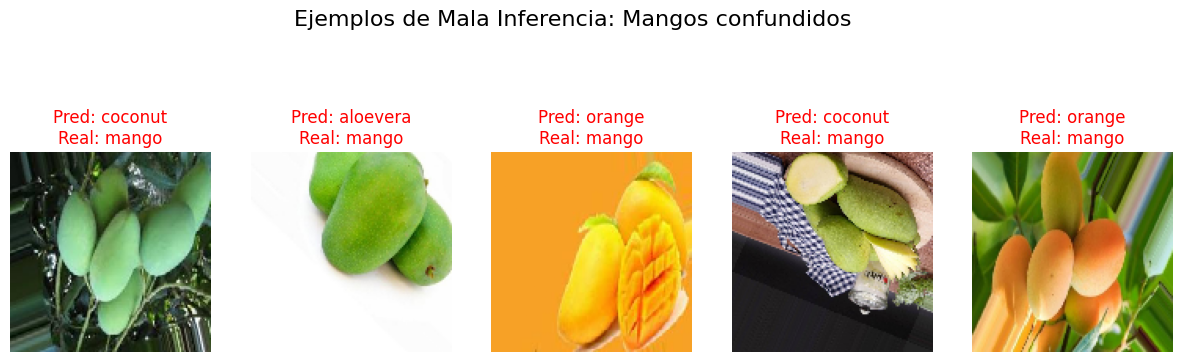

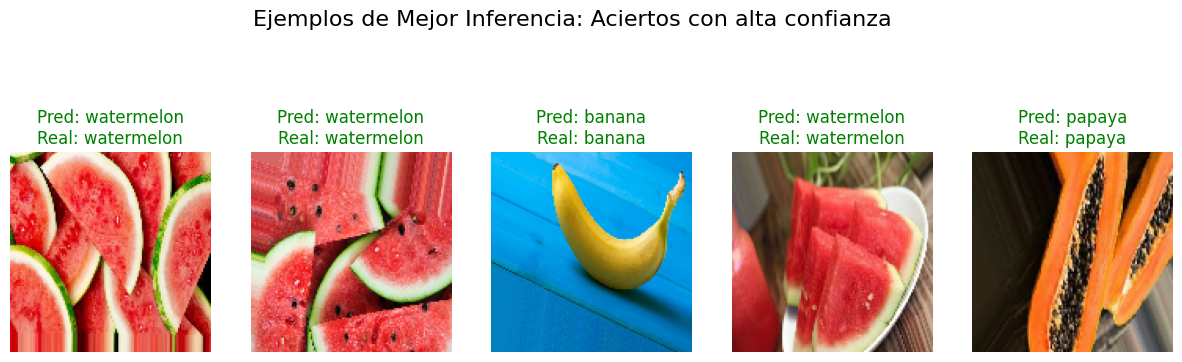

In [ ]:
# ============================
# 8. EJEMPLOS DE MEJOR Y PEOR INFERENCIA
# ============================
import matplotlib.pyplot as plt
import numpy as np

def plot_examples(indices, title):
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices[:5]):
        img, label = test_data[idx // batch_size]
        img = img[idx % batch_size]

        pred_prob = predictions[idx]
        pred_label = class_labels[np.argmax(pred_prob)]
        true_label = class_labels[y_true[idx]]

        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}\nReal: {true_label}", color=('green' if pred_label == true_label else 'red'))
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.show()

# 1. Buscar fallos específicos en Mango (Recall bajo)
mango_idx = class_labels.index('mango')
wrong_mango_indices = np.where((y_true == mango_idx) & (y_pred != mango_idx))[0]

# 2. Buscar los mejores aciertos (Probabilidad más alta)
correct_indices = np.where(y_true == y_pred)[0]
best_correct_indices = correct_indices[np.argsort(np.max(predictions[correct_indices], axis=1))[-5:]]

if len(wrong_mango_indices) > 0:
    plot_examples(wrong_mango_indices, "Ejemplos de Mala Inferencia: Mangos confundidos")
else:
    print("No se encontraron fallos en mangos en esta muestra.")

plot_examples(best_correct_indices, "Ejemplos de Mejor Inferencia: Aciertos con alta confianza")

In [ ]:
# ==========================================
# 8. RESUMEN GLOBAL DEL MODELO Y RESULTADOS
# ==========================================
import pandas as pd
from IPython.display import display

# 1. Descripción de la arquitectura del modelo
print("="*50)
print("1. ARQUITECTURA DEL MODELO")
print("="*50)
model.summary()

# 2. Métricas relevantes del entrenamiento (Última Época)
print("\n" + "="*50)
print("2. MÉTRICAS DE ENTRENAMIENTO Y VALIDACIÓN")
print("="*50)

# Obtener métricas y número de épocas
num_epochs = len(history.epoch)  # <--- AQUÍ EXTRAEMOS LAS ÉPOCAS
train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]
val_acc = history.history['val_accuracy'][-1]
val_loss = history.history['val_loss'][-1]

print(f"Total de épocas entrenadas         : {num_epochs}") # <--- LO IMPRIMIMOS AQUÍ
print("-" * 50)
print(f"Precisión (Accuracy) Entrenamiento : {train_acc:.4f} ({(train_acc*100):.2f}%)")
print(f"Pérdida (Loss) Entrenamiento       : {train_loss:.4f}")
print(f"Precisión (Accuracy) Validación    : {val_acc:.4f} ({(val_acc*100):.2f}%)")
print(f"Pérdida (Loss) Validación          : {val_loss:.4f}")

# 3. Resultados de Evaluación en el Conjunto de Prueba
print("\n" + "="*50)
print("3. RESULTADOS EN EL CONJUNTO DE PRUEBA")
print("="*50)
print(f"Precisión Global (Test Accuracy)   : {test_acc:.4f} ({(test_acc*100):.2f}%)")

# 4. Mostrar reporte de clasificación como un DataFrame
print("\n" + "="*50)
print("4. REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE")
print("="*50)
# Obtenemos el reporte como diccionario para convertirlo en tabla
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.round(4) # Redondeamos para mayor limpieza visual
display(df_report)

# 5. Conclusión General del Ajuste
print("\n" + "="*50)
print("5. DIAGNÓSTICO FINAL DEL MODELO")
print("="*50)
if val_loss > train_loss * 1.3:
    print("⚠️ RESULTADO: El modelo presenta OVERFITTING (sobreajuste).")
    print("💡 SUGERENCIA: Intenta aumentar el valor de Dropout, usar EarlyStopping o aplicar más Data Augmentation.")
elif val_loss < train_loss * 0.7:
    print("⚠️ RESULTADO: El modelo presenta UNDERFITTING (subajuste).")
    print("💡 SUGERENCIA: Entrena por más épocas o disminuye la regularización/Dropout.")
else:
    print("✅ RESULTADO: El modelo tiene un BUEN AJUSTE general.")
    print("💡 CONCLUSIÓN: La red es capaz de generalizar los datos adecuadamente sin memorizarlos.")


1. ARQUITECTURA DEL MODELO


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,098,199 (19.45 MB)

 Trainable params: 1,699,399 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,398,800 (12.97 MB)


2. MÉTRICAS DE ENTRENAMIENTO Y VALIDACIÓN
Total de épocas entrenadas         : 10
--------------------------------------------------
Precisión (Accuracy) Entrenamiento : 0.6510 (65.10%)
Pérdida (Loss) Entrenamiento       : 1.2061
Precisión (Accuracy) Validación    : 0.7394 (73.94%)
Pérdida (Loss) Validación          : 0.9470

3. RESULTADOS EN EL CONJUNTO DE PRUEBA
Precisión Global (Test Accuracy)   : 0.7257 (72.57%)

4. REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE


,precision,recall,f1-score,support
aloevera,0.6377,0.8800,0.7395,100.0000
banana,0.8037,0.8600,0.8309,100.0000
coconut,0.7083,0.8500,0.7727,100.0000
mango,0.6471,0.3300,0.4371,100.0000
orange,0.6091,0.6700,0.6381,100.0000
papaya,0.7714,0.8100,0.7902,100.0000
watermelon,0.9855,0.6800,0.8047,100.0000
accuracy,0.7257,0.7257,0.7257,0.7257
macro avg,0.7375,0.7257,0.7162,700.0000
weighted avg,0.7375,0.7257,0.7162,700.0000



5. DIAGNÓSTICO FINAL DEL MODELO
✅ RESULTADO: El modelo tiene un BUEN AJUSTE general.
💡 CONCLUSIÓN: La red es capaz de generalizar los datos adecuadamente sin memorizarlos.
